# Problem Sheet 2 — Yang Cheng, yacheng@mpia.de

This time there is no simulation data, the whole sheet is about building my own (small) cosmology calculator in plain Python/numpy, no astropy allowed. I'll just go function by function, problem by problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Build your own Python Cosmological Calculator (Part I)

### 1.1 — Einstein-de Sitter Universe

EdS: $\Omega_m=1$, $\Omega_\Lambda=0$, $k=0$. Closed-form solutions from the lecture:

- $\Omega_m(z) = 1$
- $H(z) = H_0(1+z)^{3/2}$
- $a(t) \propto t^{2/3}$, $\; t_0 = \dfrac{2}{3H_0}$
- $t(z) = t_0(1+z)^{-3/2}$
- $d_{com}(z) = c\displaystyle\int_0^z \dfrac{dz'}{H(z')} = \dfrac{2c}{H_0}\left(1-\dfrac{1}{\sqrt{1+z}}\right)$
- $d_{phys}(z) = \dfrac{d_{com}(z)}{1+z}$

I use H0 = 70 km/s/Mpc, c = 299792.458 km/s.

In [2]:
c = 299792.458   # km/s
H0 = 70          # km/s/Mpc
h = H0/100

Mpc_km = 3.0857e19   # km in 1 Mpc
Gyr_s = 3.156e16     # s in 1 Gyr
tH = Mpc_km / H0 / Gyr_s   # Hubble time 1/H0, in Gyr

rho_crit0 = 1.88e-29 * h**2   # g/cm^3, critical density today (from the lecture)

def H_EdS(z):
    return H0 * (1+z)**1.5

def rho_crit_EdS(z):
    return rho_crit0 * (H_EdS(z)/H0)**2

def rho_m_EdS(z):
    Omega_m0 = 1   # EdS by definition
    return Omega_m0 * rho_crit0 * (1+z)**3

def Omega_m_EdS(z):
    return rho_m_EdS(z) / rho_crit_EdS(z)

def t_EdS(z):
    t0 = 2/3 * tH
    return t0 * (1+z)**-1.5

def a_of_t_EdS(t):
    t0 = 2/3 * tH
    return (t/t0)**(2/3)

def d_com_EdS(z):
    return 2*c/H0 * (1 - 1/np.sqrt(1+z))

def d_phys_EdS(z):
    return d_com_EdS(z) / (1+z)

### Plot H(z), Omega_m(z), d_com(z), d_phys(z), t(z) vs z, and a(t) vs t

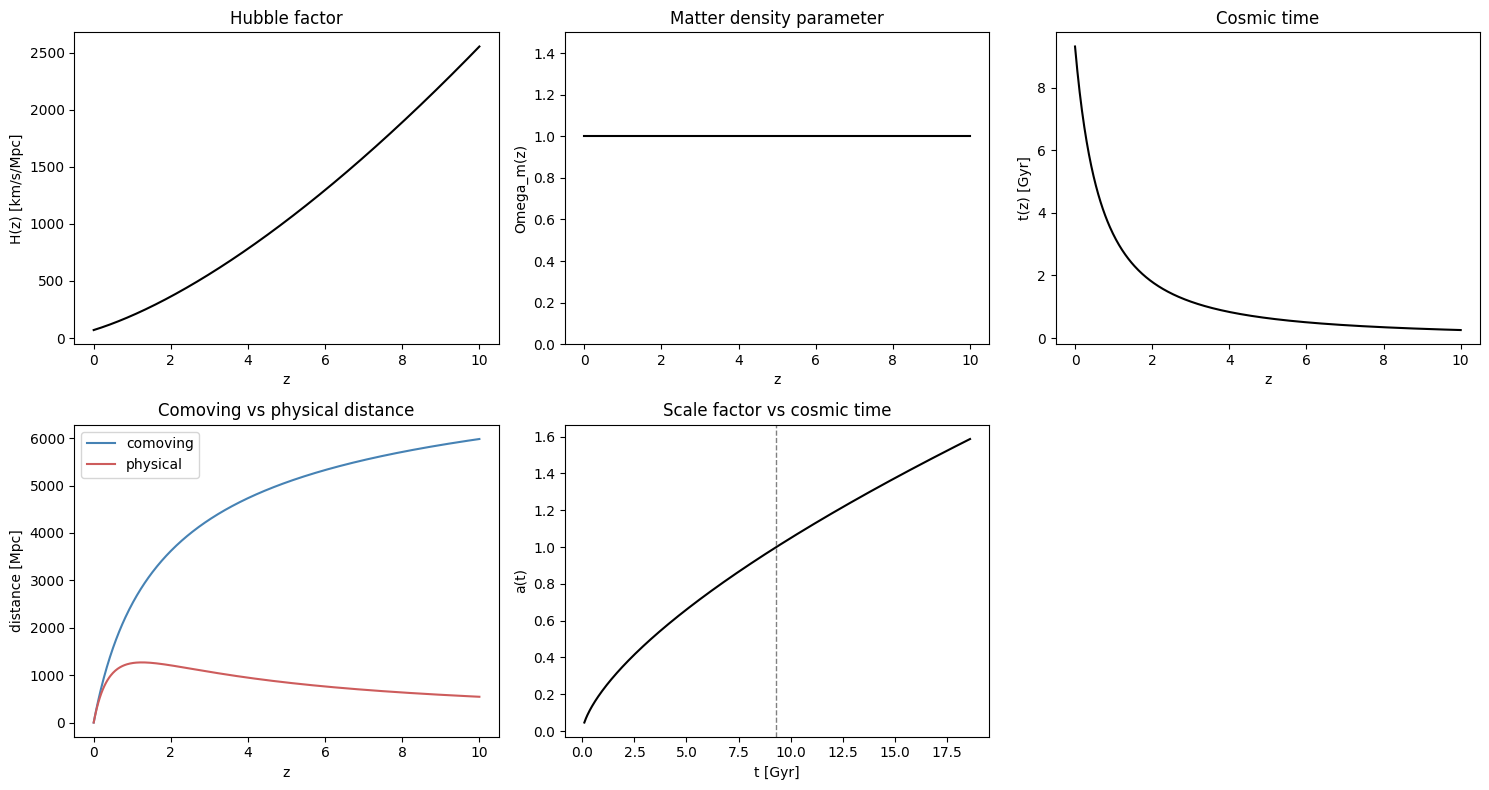

In [3]:
t0 = 2/3 * tH   # age of the universe today, Gyr

z = np.linspace(0, 10, 500)
t_ranges = np.linspace(0.01*t0, 2*t0, 500)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].plot(z, H_EdS(z), color='black')
axes[0,0].set(xlabel='z', ylabel='H(z) [km/s/Mpc]', title='Hubble factor')

axes[0,1].plot(z, Omega_m_EdS(z), color='black')
axes[0,1].set(xlabel='z', ylabel='Omega_m(z)', title='Matter density parameter')
axes[0,1].set_ylim(0, 1.5)

axes[0,2].plot(z, t_EdS(z), color='black')
axes[0,2].set(xlabel='z', ylabel='t(z) [Gyr]', title='Cosmic time')

axes[1,0].plot(z, d_com_EdS(z), color='steelblue', label='comoving')
axes[1,0].plot(z, d_phys_EdS(z), color='indianred', label='physical')
axes[1,0].set(xlabel='z', ylabel='distance [Mpc]', title='Comoving vs physical distance')
axes[1,0].legend()

axes[1,1].plot(t_ranges, a_of_t_EdS(t_ranges), color='black')
axes[1,1].axvline(t0, color='gray', ls='--', lw=1)
axes[1,1].set(xlabel='t [Gyr]', ylabel='a(t)', title='Scale factor vs cosmic time')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

### 1.1 small discussion

The parameters ploted here bahave as expected for the EdS universe: H(z) grows with(1+z)^1.5 and Omega_m(z) is constant. t(z) drops fast towards the Big Bang at high z, consistent with t0 ~ 9.3 Gyr for H0=70. The comoving distance d_com(z) flattens off at high z, while the physical distance d_phys(z) peaks around z~1.2 and goes back down. Finally a(t) grows like t^(2/3), as expected and already shown in the lecture.

### 1.2 — Matter-dominated Universe with arbitrary $\Omega_m$

Now $\Omega_m$ is free and $\Omega_\Lambda=0$: then by definition there is an extra curvature component, $\Omega_k = 1-\Omega_m$. General $H(z)$ from the lecture is then transformed into:

$H(z) \overset{\Omega_r,\Omega_\Lambda = 0}{=} H_0\sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)(1+z)^2}$

$\Omega_m(z) = \rho_m(z)/\rho_{crit}(z) \overset{matter}{=}  \left(\Omega_m \times \rho_{crit,0} \times a^{-3}\right) / \left(\rho_{crit}(z) \right) $

Now since $\rho_{crit}(z) = 3H(z)^2/(8\pi G)$, we can write: $\rho_{crit}(z)/ \rho_{crit,0} = H(z)^2/H_0^2 = E(z)^2$, so we can write:

$\Omega_m(z) = \Omega_m(1+z)^3/E(z)^2$

The following parameters are now defined by the integrals:

$t(z) = \displaystyle\int_0^{a(z)} \frac{da'}{a'H(a')}$, with $a(z)=1/(1+z)$

$d_{com}(z) = c\displaystyle\int_0^z \frac{dz'}{H(z')}$

$d_{phys}(z) = d_{com}(z)/(1+z)$

I keep $H_0=70$ km/s/Mpc like in 1.1, and try to use $\Omega_m$ = 1, 0.7, 0.3 for the plots. I also use scipy integrad to numerically compute the parameters shown above.

In [4]:
from scipy.integrate import quad

def H_matter(z, Om):
    return H0 * np.sqrt(Om*(1+z)**3 + (1-Om)*(1+z)**2)

def Omega_m_matter(z, Om):
    E2 = (H_matter(z, Om)/H0)**2
    return Om*(1+z)**3 / E2

def t_matter(z, Om):
    a = 1/(1+z)
    integrand = lambda ap: 1/(ap*H_matter(1/ap - 1, Om))
    val, _ = quad(integrand, 1e-8, a)   # 1e-8 instead of 0 to dodge the 1/ap blow-up right at a'=0
    return val * Mpc_km/Gyr_s   # convert 1/(km/s/Mpc) -> Gyr, same factor as tH in 1.1

def d_com_matter(z, Om):
    integrand = lambda zp: c/H_matter(zp, Om)
    val, _ = quad(integrand, 0, z)
    return val

def d_phys_matter(z, Om):
    return d_com_matter(z, Om) / (1+z)

Quick check between my numerical integrals vs astropy:

In [5]:
from astropy.cosmology import LambdaCDM   # only here, just to validate my own functions

Om_test, z_test = 0.7, 2
astropy_check = LambdaCDM(H0=H0, Om0=Om_test, Ode0=0)

print('H(z)   mine/astropy:', H_matter(z_test, Om_test), astropy_check.H(z_test).value)
print('t(z)   mine/astropy:', t_matter(z_test, Om_test), astropy_check.age(z_test).value)
print('d_com  mine/astropy:', d_com_matter(z_test, Om_test), astropy_check.comoving_distance(z_test).value)
print('d_phys mine/astropy:', d_phys_matter(z_test, Om_test), astropy_check.angular_diameter_distance(z_test).value)

H(z)   mine/astropy: 325.330601081423 325.33060108142297
t(z)   mine/astropy: 2.056526293291775 2.0566677525773667
d_com  mine/astropy: 3841.1487043476504 3841.148704347651
d_phys mine/astropy: 1280.382901449217 1332.5054362206351


### Plot H(z), Omega_m(z), d_com(z), d_phys(z), t(z) for Omega_m = 1, 0.7, 0.3

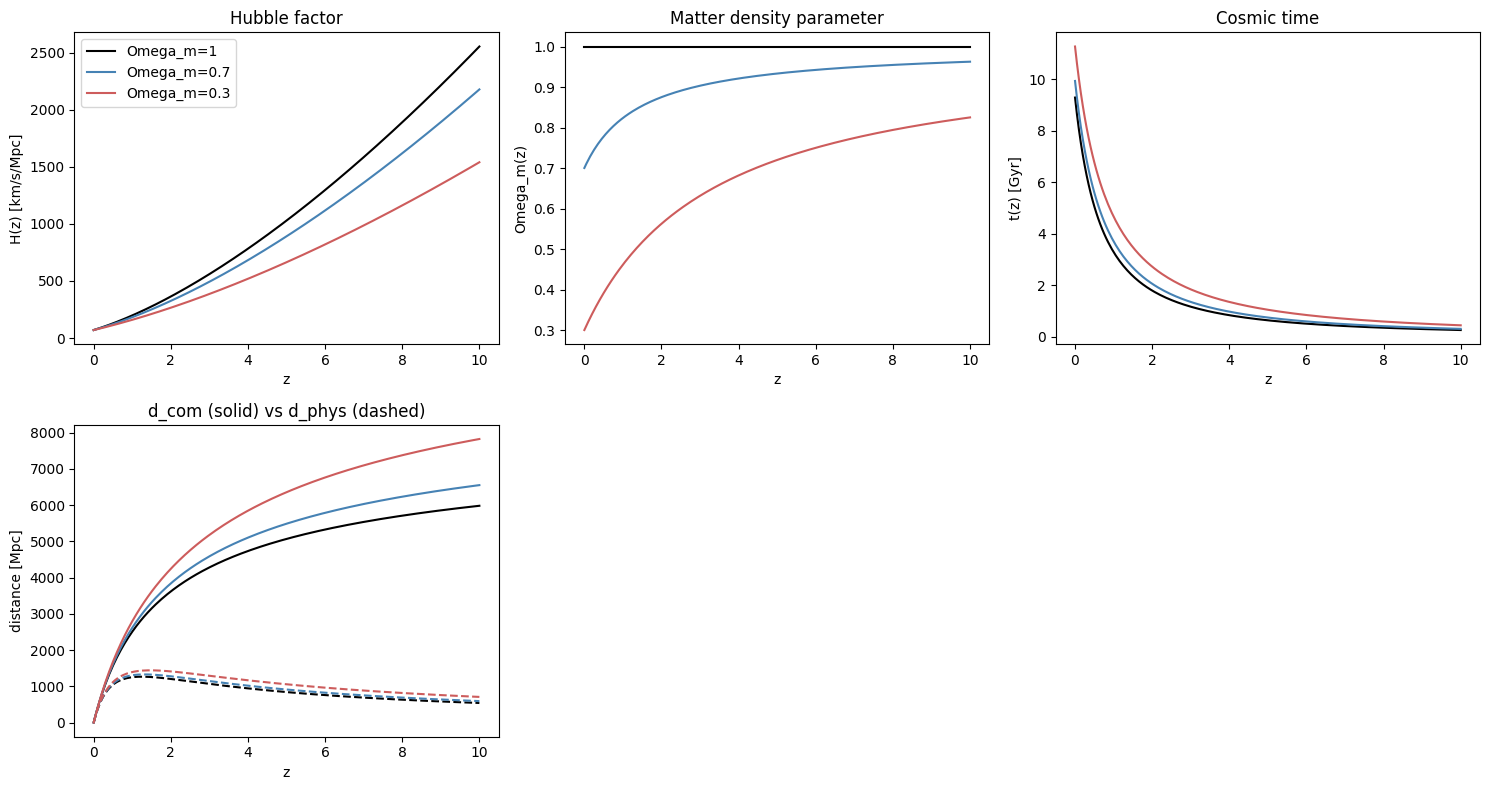

In [6]:
z = np.linspace(0.001, 10, 200)
Om_list = [1, 0.7, 0.3]
colors = ['black', 'steelblue', 'indianred']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for Om, col in zip(Om_list, colors):
    axes[0,0].plot(z, H_matter(z, Om), color=col, label=f'Omega_m={Om}')
    axes[0,1].plot(z, Omega_m_matter(z, Om), color=col)
    axes[0,2].plot(z, [t_matter(zi, Om) for zi in z], color=col)
    axes[1,0].plot(z, [d_com_matter(zi, Om) for zi in z], color=col, ls='-')
    axes[1,0].plot(z, [d_phys_matter(zi, Om) for zi in z], color=col, ls='--')

axes[0,0].set(xlabel='z', ylabel='H(z) [km/s/Mpc]', title='Hubble factor')
axes[0,0].legend()
axes[0,1].set(xlabel='z', ylabel='Omega_m(z)', title='Matter density parameter')
axes[0,2].set(xlabel='z', ylabel='t(z) [Gyr]', title='Cosmic time')
axes[1,0].set(xlabel='z', ylabel='distance [Mpc]', title='d_com (solid) vs d_phys (dashed)')
axes[1,1].axis('off')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

### 1.2 small discussion

The Omega_m=1 curves match the EdS ones from 1.1 exactly. Lower Omega_m means gives more curvature (open universe) picking up the rest of the budget, and the effect is that the expansion decelerates less: H(z) is higher today relatively speaking, the universe is older (larger t(z) at fixed z, so bigger t0), and distances are larger at fixed z too. Omega_m(z) still goes to 1 at high z for every curve: whatever the curvature today, matter always wins at early times since it scales as (1+z)^3.

### 1.3 — General cosmology: curvature + $\Lambda$

to generalize the function to non-flat models: i.e. any $\Omega_m,\Omega_r,\Omega_\Lambda$, with $\Omega_k=1-\Omega_m-\Omega_r-\Omega_\Lambda$ picking up the rest. General Friedmann equation from the lecture:

$H(z) = H_0\sqrt{\Omega_r(1+z)^4+\Omega_m(1+z)^3+\Omega_k(1+z)^2+\Omega_\Lambda}$

$\Omega_i(z) = \rho_i(z)/\rho_{crit}(z) \overset{\text{same as } 1.2}{=}  \Omega_{i,0}(1+z)^{n_i}/E(z)^2$, with $n_r=4$, $n_m=3$, $n_\Lambda=0$

Same integrals as 1.2, just with this more general $H(z)$ (taken from the lecture, (or note 2.1)):

$t(z) = \displaystyle\int_0^{a(z)}\frac{da'}{a'H(a')}$

$d_{com}(z) = c\displaystyle\int_0^z\frac{dz'}{H(z')}$

$d_{phys}(z) = d_{com}(z)/(1+z)$

Parameters: EdS same as 1.1/1.2 ($\Omega_m=1$, everything else 0, $H_0=70$). LCDM from Table 8.2 in the problem sheet: $\Omega_m=0.315$, $\Omega_\Lambda=0.685$, $H_0=67.3$, $\Omega_r=2.47\times10^{-5}h^{-2}$.

In [7]:
def H_gen(z, Om, Or, OL, H0):
    Ok = 1 - Om - Or - OL
    return H0 * np.sqrt(Or*(1+z)**4 + Om*(1+z)**3 + Ok*(1+z)**2 + OL)

def Omega_i_gen(z, Oi0, n, Om, Or, OL, H0):
    E2 = (H_gen(z, Om, Or, OL, H0)/H0)**2
    return Oi0*(1+z)**n / E2

def t_gen(z, Om, Or, OL, H0):
    a = 1/(1+z)
    integrand = lambda ap: 1/(ap*H_gen(1/ap - 1, Om, Or, OL, H0))
    val, _ = quad(integrand, 1e-8, a)
    return val * Mpc_km/Gyr_s

def d_com_gen(z, Om, Or, OL, H0):
    integrand = lambda zp: c/H_gen(zp, Om, Or, OL, H0)
    val, _ = quad(integrand, 0, z)
    return val

def d_phys_gen(z, Om, Or, OL, H0):
    return d_com_gen(z, Om, Or, OL, H0) / (1+z)

#2 special cases hard coded here:
# EdS, same as 1.1/1.2
eds = dict(Om=1, Or=0, OL=0, H0=70)

# LCDM
H0_lcdm = 67.3; h_lcdm = H0_lcdm/100
lcdm = dict(Om=0.315, Or=2.47e-5/h_lcdm**2, OL=0.685, H0=H0_lcdm)

print('EdS :', eds)
print('LCDM:', lcdm)

EdS : {'Om': 1, 'Or': 0, 'OL': 0, 'H0': 70}
LCDM: {'Om': 0.315, 'Or': 5.453393357457793e-05, 'OL': 0.685, 'H0': 67.3}


### Plot H(z), d_com/d_phys(z), t(z), a(t): EdS vs LCDM

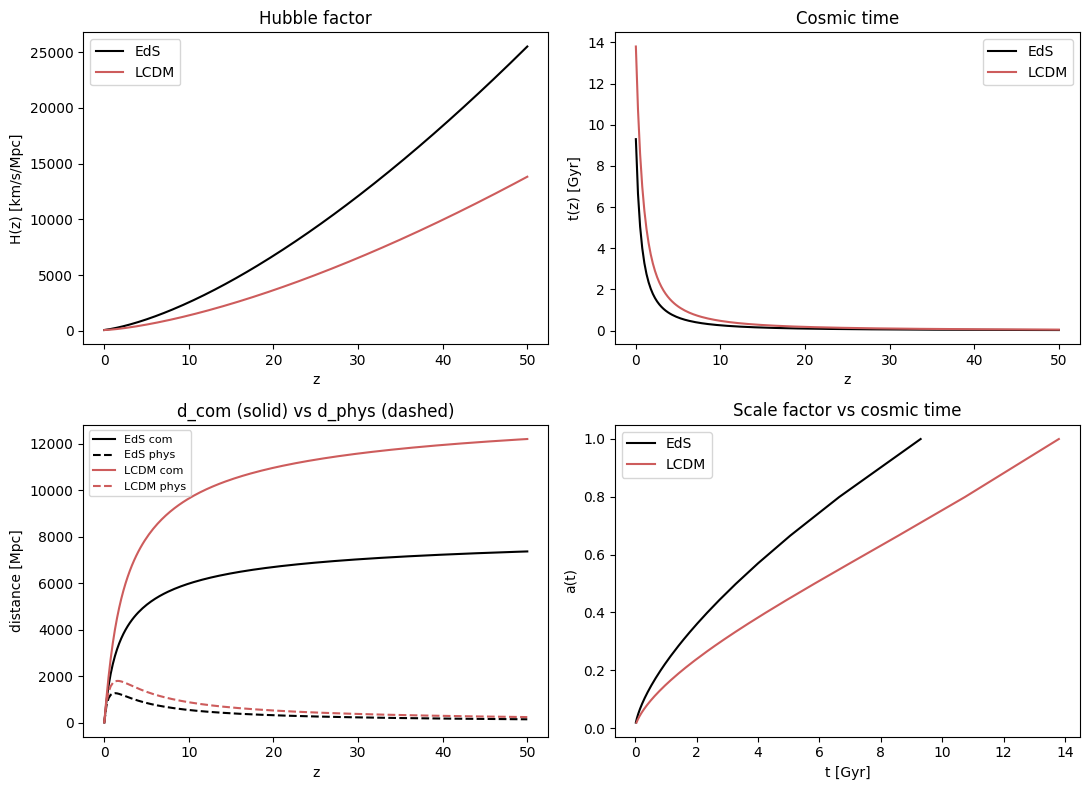

In [8]:
z = np.linspace(0.001, 50, 200)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for cosmo, label, col in [(eds, 'EdS', 'black'), (lcdm, 'LCDM', 'indianred')]:
    Hz = H_gen(z, cosmo['Om'], cosmo['Or'], cosmo['OL'], cosmo['H0'])
    tz = np.array([t_gen(zi, cosmo['Om'], cosmo['Or'], cosmo['OL'], cosmo['H0']) for zi in z])
    dcom = np.array([d_com_gen(zi, cosmo['Om'], cosmo['Or'], cosmo['OL'], cosmo['H0']) for zi in z])
    dphys = dcom / (1+z)
    a = 1/(1+z)

    axes[0,0].plot(z, Hz, color=col, label=label)
    axes[0,1].plot(z, tz, color=col, label=label)
    axes[1,0].plot(z, dcom, color=col, ls='-', label=f'{label} com')
    axes[1,0].plot(z, dphys, color=col, ls='--', label=f'{label} phys')
    axes[1,1].plot(tz, a, color=col, label=label)

axes[0,0].set(xlabel='z', ylabel='H(z) [km/s/Mpc]', title='Hubble factor')
axes[0,0].legend()
axes[0,1].set(xlabel='z', ylabel='t(z) [Gyr]', title='Cosmic time')
axes[0,1].legend()
axes[1,0].set(xlabel='z', ylabel='distance [Mpc]', title='d_com (solid) vs d_phys (dashed)')
axes[1,0].legend(fontsize=8)
axes[1,1].set(xlabel='t [Gyr]', ylabel='a(t)', title='Scale factor vs cosmic time')
axes[1,1].legend()

plt.tight_layout()
plt.show()

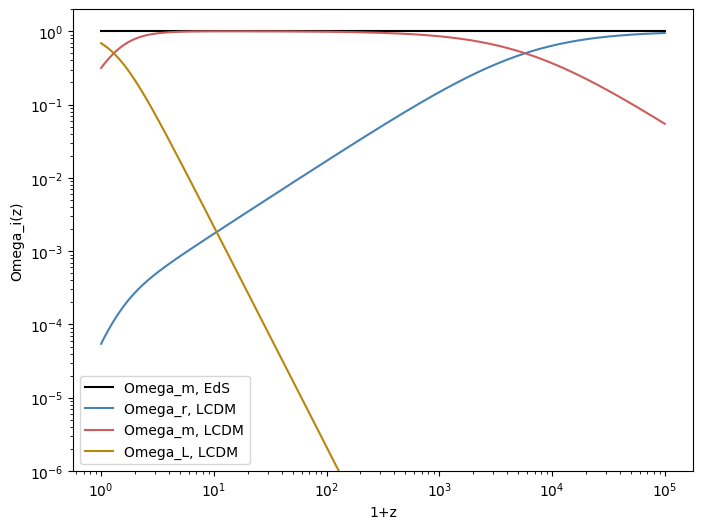

In [9]:
zp1 = np.logspace(0, 5, 300)   # 1+z from 1 to 1e5
zz = zp1 - 1

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(zp1, Omega_i_gen(zz, eds['Om'], 3, eds['Om'], eds['Or'], eds['OL'], eds['H0']),
        color='black', label='Omega_m, EdS')

ax.plot(zp1, Omega_i_gen(zz, lcdm['Or'], 4, lcdm['Om'], lcdm['Or'], lcdm['OL'], lcdm['H0']),
        color='steelblue', label='Omega_r, LCDM')
ax.plot(zp1, Omega_i_gen(zz, lcdm['Om'], 3, lcdm['Om'], lcdm['Or'], lcdm['OL'], lcdm['H0']),
        color='indianred', label='Omega_m, LCDM')
ax.plot(zp1, Omega_i_gen(zz, lcdm['OL'], 0, lcdm['Om'], lcdm['Or'], lcdm['OL'], lcdm['H0']),
        color='darkgoldenrod', label='Omega_L, LCDM')

ax.set(xscale='log', yscale='log', xlabel='1+z', ylabel='Omega_i(z)', ylim=(1e-6, 2))
ax.legend()
plt.show()

### 1.3 small discussion

H(z) the distances values all converge to the same at low z for EdS and LCDM, but they diverge fast going to higher z. EdS H(z) grows faster with z, since there's no dark energy slowing the deceleration down today. The Omega_i(z) panel shows the evolution of the density parameters. For EdS there is only single component of matter that is held fixed. In LCDM, with manually set vlaues, we can see that Omega_L~0.685 at z=0 drops fastest towards high z, when the matter grows higher than Omega_L around z~0.3-0.5, then at very high z (~3000, matter-radiation equality) radiation would dominate.

## 2. The evolution of the densities of the various components of the Universe

### 2.1 — How the densities evolve with redshift

The same relation in 1.2 and 1.3 is directly used here:

$\Omega_i(z) \doteq \dfrac{\rho_i(z)}{\rho_{crit}(z)} = \dfrac{\Omega_{i,0}(1+z)^{n_i}}{E(z)^2}$

As required the computation uses directly the functions defined in 1.3 above, where different component is defined with different power of (1+z): $n_r=4$, $n_m=3$, $n_\Lambda=0$. 


The problem asks to normalize every densities in terms of the critical density: I assume the proper densities means $\rho_i(z) / \rho_{crit,0}$, not the $\Omega_i$, in three cases: $\Omega_m,\Omega_\Lambda$ = (1, 0), (0.3, 0) and (0.3, 0.7) + $h=0.7$ (used for radiation term). I also keep $\Omega_r = 2.47\times10^{-5}h^{-2}$ in all three scenarios, and $\Omega_k = 1-\Omega_m-\Omega_r-\Omega_\Lambda$ picks up whatever is missing.

In [10]:
Or_h07 = 2.47e-5 / 0.7**2          # radiation density parameter today, for h=0.7

scenarios = {
    'EdS (Om=1, OL=0)':          dict(Om=1.0, Or=Or_h07, OL=0.0, H0=70),
    'Low-density (Om=0.3, OL=0)': dict(Om=0.3, Or=Or_h07, OL=0.0, H0=70),
    'LCDM (Om=0.3, OL=0.7)':     dict(Om=0.3, Or=Or_h07, OL=0.7, H0=70),
}

n_i = dict(r=4, m=3, L=0)   # just three components exponents

def rho_over_rhocrit0(z, cosmo, comp):
    # computes the normalized rho/rho_crit,0, given the cosmo parameters in the dict
    Oi0 = {'r': cosmo['Or'], 'm': cosmo['Om'], 'L': cosmo['OL']}[comp]
    return Oi0 * (1+z)**n_i[comp]

def Omega_of_z(z, cosmo, comp):
    # just Omega_i_gen from 1.3, wrapped for convenience
    Oi0 = {'r': cosmo['Or'], 'm': cosmo['Om'], 'L': cosmo['OL']}[comp]
    return Omega_i_gen(z, Oi0, n_i[comp], cosmo['Om'], cosmo['Or'], cosmo['OL'], cosmo['H0'])

print('compute in the following three cases:')
for name, cosmo in scenarios.items():
    #curvature term as 1 - all the rest
    Ok = 1 - cosmo['Om'] - cosmo['Or'] - cosmo['OL']
    print(f"{name:28s} Om={cosmo['Om']:.1f}  Or={cosmo['Or']:.3e}  OL={cosmo['OL']:.1f}  Ok={Ok:+.3f}")

compute in the following three cases:
EdS (Om=1, OL=0)             Om=1.0  Or=5.041e-05  OL=0.0  Ok=-0.000
Low-density (Om=0.3, OL=0)   Om=0.3  Or=5.041e-05  OL=0.0  Ok=+0.700
LCDM (Om=0.3, OL=0.7)        Om=0.3  Or=5.041e-05  OL=0.7  Ok=-0.000


### Plot: physical densities and density parameters vs 1+z, in the three scenarios

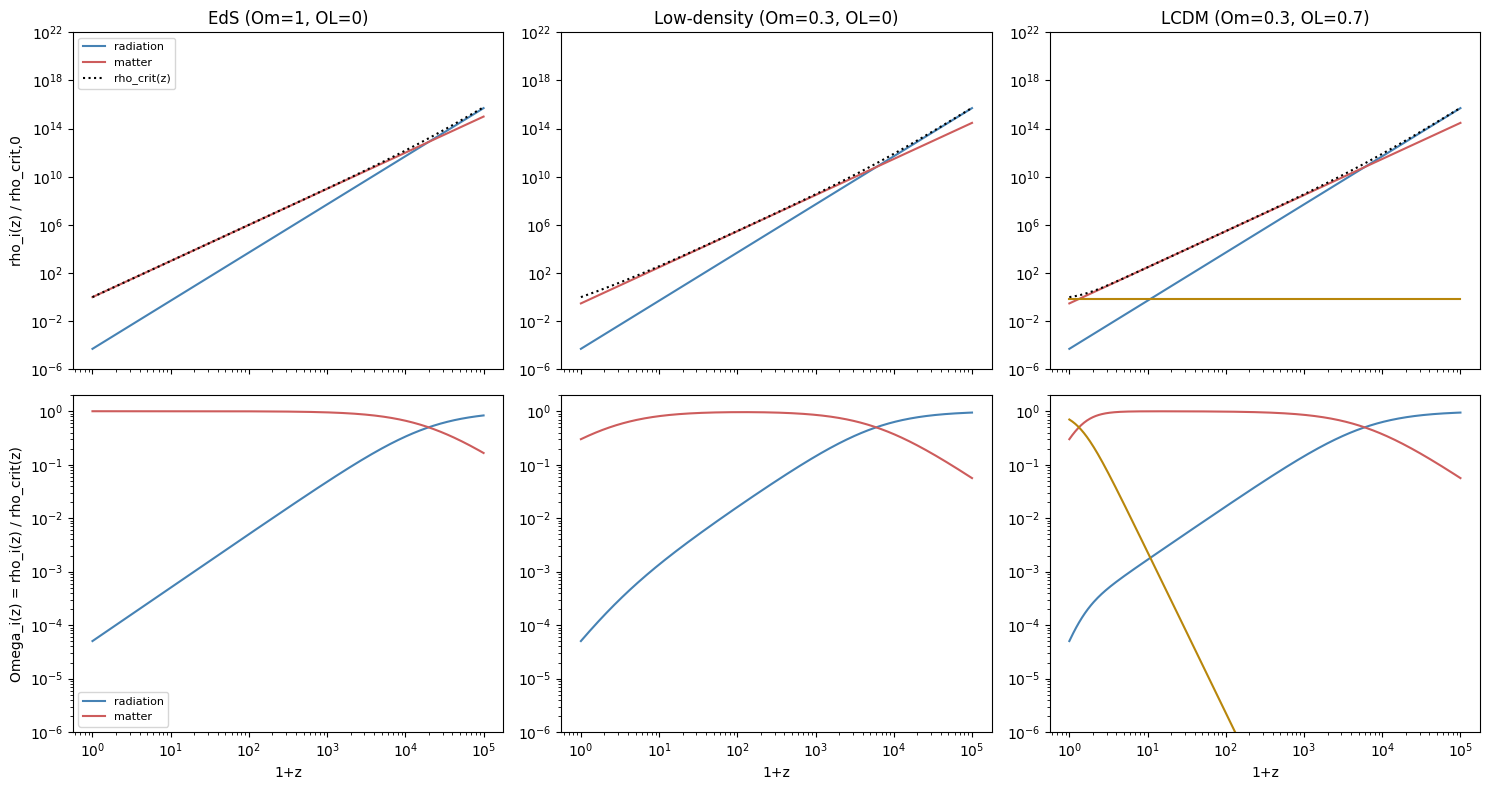

In [11]:
zp1 = np.logspace(0, 5, 400)   # 1+z from 1 to 1e5, same x-range as the figure on slide 19
zz  = zp1 - 1

comps  = ['r', 'm', 'L']
labels = {'r': 'radiation', 'm': 'matter', 'L': 'dark energy (Lambda)'}
colors = {'r': 'steelblue', 'm': 'indianred', 'L': 'darkgoldenrod'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for j, (name, cosmo) in enumerate(scenarios.items()):
    for comp in comps:
        rho = rho_over_rhocrit0(zz, cosmo, comp)
        if np.all(rho == 0):
            continue   # no Lambda in EdS / low-density
        axes[0, j].plot(zp1, rho, color=colors[comp], label=labels[comp])
        axes[1, j].plot(zp1, Omega_of_z(zz, cosmo, comp), color=colors[comp], label=labels[comp])
    # rho_crit(z)/rho_crit,0 = (H_gen(z)/H0)^2, straight from the 1.3 function
    rho_crit_ratio = (H_gen(zz, cosmo['Om'], cosmo['Or'], cosmo['OL'], cosmo['H0']) / cosmo['H0'])**2
    axes[0, j].plot(zp1, rho_crit_ratio, color='black', ls=':', label='rho_crit(z)')
    axes[0, j].set(title=name, xscale='log', yscale='log', ylim=(1e-6, 1e22))
    axes[1, j].set(xscale='log', yscale='log', ylim=(1e-6, 2), xlabel='1+z')

axes[0,0].set_ylabel('rho_i(z) / rho_crit,0')
axes[1,0].set_ylabel('Omega_i(z) = rho_i(z) / rho_crit(z)')
axes[0,0].legend(fontsize=8, loc='upper left')
axes[1,0].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

### 2.1 small discussion

Top row are straight lines in log-log which simply reflects the power laws exponent of slopes 4, 3, 0, as expected from the intro of the lecture. I also add the Bottom row of the big $\Omega_i$ which is essentially normalized by $\rho_{crit}(z)$: the same behavior we have seen in the previous plots.

### 2.2 — The three equivalence epochs, the eras, and two events in cosmic history

Equivalence epoch means the time when 2 components gives $\rho_i = \rho_j$. With $\rho_i(z)=\Omega_{i,0}\rho_{crit,0}(1+z)^{n_i}$ we set the:

$\Omega_{i,0}(1+z)^{n_i} = \Omega_{j,0}(1+z)^{n_j} \;\Longrightarrow\; 1+z = \left(\dfrac{\Omega_{j,0}}{\Omega_{i,0}}\right)^{1/(n_i-n_j)}$

where $\rho_{crit}$ cancels in all of these, and we can compute this analytically.

In [12]:
#read the predefined LCDM 
lcdm_std = scenarios['LCDM (Om=0.3, OL=0.7)']
Om, Or, OL = lcdm_std['Om'], lcdm_std['Or'], lcdm_std['OL']

z_rm = Om/Or - 1            # radiation = matter
z_mL = (OL/Om)**(1/3) - 1   # matter = Lambda
z_rL = (OL/Or)**(1/4) - 1   # radiation = Lambda

print(f'radiation = matter  : z = {z_rm:9.1f}')
print(f'matter    = Lambda  : z = {z_mL:9.4f}')
print(f'radiation = Lambda  : z = {z_rL:9.3f}')

t0_std = t_gen(0, **lcdm_std)
print(f'\nage of the universe today   t0      = {t0_std:.3f} Gyr')
print(f'age at radiation-matter eq. t(z_rm) = {t_gen(z_rm, **lcdm_std)*1e3:.4f} Myr')
print(f'age at matter-Lambda eq.    t(z_mL) = {t_gen(z_mL, **lcdm_std):.3f} Gyr')

radiation = matter  : z =    5950.4
matter    = Lambda  : z =    0.3264
radiation = Lambda  : z =     9.855

age of the universe today   t0      = 13.463 Gyr
age at radiation-matter eq. t(z_rm) = 0.0217 Myr
age at matter-Lambda eq.    t(z_mL) = 9.806 Gyr


### Plot: the three eras of LCDM

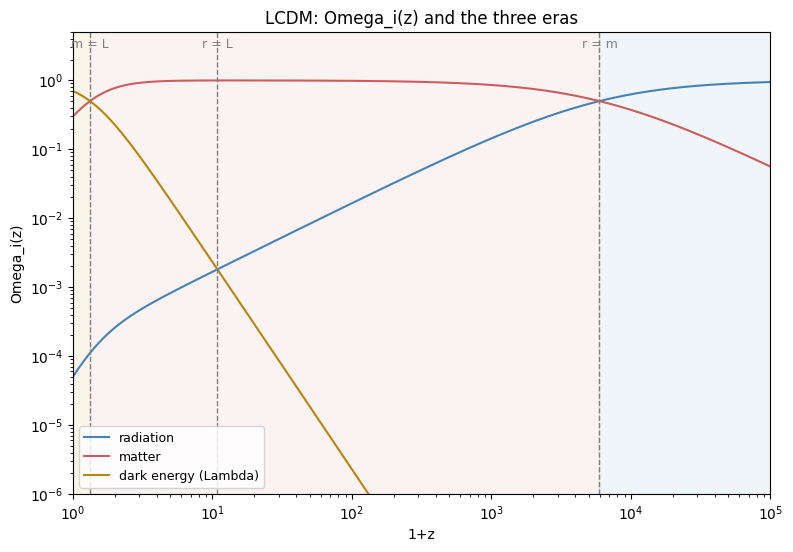

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for comp in comps:
    ax.plot(zp1, Omega_of_z(zz, lcdm_std, comp), color=colors[comp], label=labels[comp])

for z_eq, lab in [(z_rm, 'r = m'), (z_mL, 'm = L'), (z_rL, 'r = L')]:
    ax.axvline(1+z_eq, color='gray', ls='--', lw=1)
    ax.text(1+z_eq, 3, lab, ha='center', fontsize=9, color='gray')

# shade the three eras
ax.axvspan(1+z_rm, zp1[-1], color='steelblue',      alpha=0.08)
ax.axvspan(1+z_mL, 1+z_rm,  color='indianred',      alpha=0.08)
ax.axvspan(zp1[0], 1+z_mL,  color='darkgoldenrod',  alpha=0.08)

ax.set(xscale='log', yscale='log', xlabel='1+z', ylabel='Omega_i(z)',
       ylim=(1e-6, 5), xlim=(1, 1e5), title='LCDM: Omega_i(z) and the three eras')
ax.legend(fontsize=9, loc='lower left')
plt.show()

### small discussion

Three equivalence redshifts in LCDM: radiation=matter around $z\sim 5950$, matter=$\Lambda$ around $z\sim 0.33$, radiation=$\Lambda$ around $z\sim9.9$. From the plot: radiation wins above $z\sim5950$, matter wins for basically the whole range down to $z\sim0.33$, dark energy takes over in the last until today.

### The Sun and the dinosaurs: inverting t(z) by interpolation

We have alrady t(z) from 1.3, and here we just interpolate over a grid of t to find the the z, I can just use the interpolate function from numpy.

Also the ages of the two events (lookback times):
- the Sun formed 4.57 Gyr ago
- the dinosaurs went extinct 66 Myr ago

In [14]:
z_grid = np.logspace(-4, 4, 3000)
t_grid = np.array([t_gen(zi, **lcdm_std) for zi in z_grid])

# t(z) is monotonically decreasing in z, so flip it to feed np.interp (which needs increasing x)
t_incr, z_incr = t_grid[::-1], z_grid[::-1]

def z_of_t(t):
    # invert the cosmic-time-redshift relation by interpolation
    return np.interp(t, t_incr, z_incr)

events = {'Sun born (4.57 Gyr ago)': 4.57, 'dinosaurs gone (66 Myr ago)': 0.066}
print()
for name, lookback in events.items():
    t_ev = t0_std - lookback
    print(f'{name:28s}: t = {t_ev:7.3f} Gyr  ->  z = {z_of_t(t_ev):.4f}')


Sun born (4.57 Gyr ago)     : t =   8.893 Gyr  ->  z = 0.4365
dinosaurs gone (66 Myr ago) : t =  13.397 Gyr  ->  z = 0.0047


## 3. The age of the Universe and the standard cosmological scenario

### 3.1 — age today, onset of acceleration, matter-$\Lambda$ equality

Same lcdm case as before, it seems I have already computed teh age of the universe in 1.3 the $t_0 = 13.46$ Gyr.

To compute the expansion/contration, one can use the 2nd Friedmann equation (an alternative form from the lecture note):

$ \ddot a / a = -\dfrac{4\pi G}{3}\sum_i (\rho_i +3 p_i) $

then we take all 3 components with $p_m = 0$, $p_r = \rho_r/3$, $p_\Lambda = -\rho_\Lambda$ (radiation vanishes bcs its rho_r is low)

$\ddot a/a \approx -\dfrac{4\pi G}{3}(\rho_m - 2\rho_\Lambda)$

Acceleration starts when $\ddot a=0$:

$\rho_m = 2\rho_\Lambda$

Using the definition of $\Omega_i (z) = \rho_i (z) / \rho_{crit}(z)$ we can rewrite the above equation and solve for redshift:

$1+z = \left(\dfrac{2\Omega_{\Lambda,0}}{\Omega_{m,0}}\right)^{1/3}$


Finally the energy density of matter is nothing but

$\epsilon_m(z) = \rho_m(z) \times c^2 \overset{c=1}{=} \rho_m(z)$

then we also have the  cosmology constant $\Lambda$ written as $\rho_\Lambda(z) = \Omega_{\Lambda,0}\rho_{crit,0}$, so I think this is equivalent to compute the redshift where the two densities are equal.

In [15]:
z_acc = (2*OL/Om)**(1/3) - 1
t_acc = t_gen(z_acc, **lcdm_std)

print(f'age of the universe today   t0    = {t0_std:.3f} Gyr')
print(f'acceleration starts at      z_acc = {z_acc:.3f}  ->  t = {t_acc:.3f} Gyr')
print(f'matter = Lambda equality    z_mL  = {z_mL:.3f}  ->  t = {t_gen(z_mL, **lcdm_std):.3f} Gyr')

age of the universe today   t0    = 13.463 Gyr
acceleration starts at      z_acc = 0.671  ->  t = 7.326 Gyr
matter = Lambda equality    z_mL  = 0.326  ->  t = 9.806 Gyr


Age today comes out to ~13.46 Gyr, acceleration kicked in around $z\sim0.67$ (about 7.3 Gyr in, just past the halfway point of cosmic history), matter-$\Lambda$ densities euqalize a bit later at $z\sim0.33$ (9.8 Gyr).

### 3.2 — essentially civilization without the knowledge of dark energy

They think it's flat with $\Omega_m=1$, $h=0.7$: so this is the EdS case from 1.1 and 1.3, we can compute the t_0 directly from the defined functions:

In [16]:
t0_ignorant = t_gen(0, **eds)

print(f'ignorant civilization age = {t0_ignorant:.3f} Gyr')
print(f'true (LCDM) age           = {t0_std:.3f} Gyr')
print(f'off by                    = {t0_std-t0_ignorant:.2f} Gyr ({(1-t0_ignorant/t0_std)*100:.1f}%)')

ignorant civilization age = 9.312 Gyr
true (LCDM) age           = 13.463 Gyr
off by                    = 4.15 Gyr (30.8%)


The ignorant civilization gets ~9.31 Gyr, off by about 4.15 Gyr LCDM. Actually I think in the field of galactic / Extragalactic astronomy, one often gets an estimate of the age of an old globular cluster to be older than this value.

## 4. Galaxies, redshift, and cosmic time

Most distant galaxies observed today are at $z=13$. Just plug in the function defined to get the required values, I also use alstropy to cross check

In [17]:
z_gal = 13

t_gal   = t_gen(z_gal, **lcdm_std)
dcom_gal  = d_com_gen(z_gal, **lcdm_std)
dphys_gal = d_phys_gen(z_gal, **lcdm_std)

from astropy.cosmology import LambdaCDM
astropy_check = LambdaCDM(H0=lcdm_std['H0'], Om0=lcdm_std['Om'], Ode0=lcdm_std['OL'])

print('t      mine/astropy:', t_gal, astropy_check.age(z_gal).value)
print('d_com  mine/astropy:', dcom_gal, astropy_check.comoving_distance(z_gal).value)
print('d_phys mine/astropy:', dphys_gal, astropy_check.angular_diameter_distance(z_gal).value)
print('this is in general consistent with one another')

t      mine/astropy: 0.3234271012934588 0.3245211958725999
d_com  mine/astropy: 9972.612717065558 9975.529841306727
d_phys mine/astropy: 712.329479790397 712.5378458076233
this is in general consistent with one another
